# GR-CLIP comparison


## Flickr30K


In [1]:
import json
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

from analysis.modality_gap import compute_gap
from comparison.grclip_implementation import (
    apply_grclip_pair,
    fit_grclip_statistics_from_loader,
    mean_rmg_over_batches,
)
from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from dataset.mscoco.mscoco_dataloader_with_imagenet_labels import (
    MSCOCOEmbeddingsDatasetWithImageNetLabels,
    mscoco_imagenet_collate_fn,
)
from dataset.msrvtt.msrvtt_dataloaderv2 import (
    MSRVTTEmbeddingsDatasetV2,
    msrvtt_v2_collate_fn,
)
from metrics.clustering import (
    _clustering_metrics_two_modalities_flickr30k,
    clustering_metrics_two_modalities_mscoco_imagenet_labels,
    clustering_metrics_two_modalities_msrvtt,
)
from metrics.retrieval import compute_retrieval

seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda:1" if torch.cuda.is_available() else "cpu"


def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)


def _compute_gap_bundle(text_embeddings, vision_embeddings):
    metrics = ["L2M", "L2I", "cosineTP"]
    return {
        metric: float(_to_scalar(compute_gap(metric, text_embeddings, vision_embeddings, iterations=None)))
        for metric in metrics
    }


def _summarize_grclip_statistics(statistics):
    return {
        "n_fit": int(statistics.get("n_fit")) if statistics.get("n_fit") is not None else None,
        "embedding_dim": int(statistics.get("embedding_dim")) if statistics.get("embedding_dim") is not None else None,
        "query_text_mean_norm": float(statistics.get("query_text_mean_norm")) if statistics.get("query_text_mean_norm") is not None else None,
        "document_text_mean_norm": float(statistics.get("document_text_mean_norm")) if statistics.get("document_text_mean_norm") is not None else None,
        "document_image_mean_norm": float(statistics.get("document_image_mean_norm")) if statistics.get("document_image_mean_norm") is not None else None,
    }


def collect_grclip_eval_embeddings(loader, statistics, device="cpu", max_eval_batches=None):
    text_buf, vision_buf, text_gr_buf, vision_gr_buf, labels_buf = [], [], [], [], []
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Collect GR-CLIP eval embeddings"):
            if not isinstance(batch, (list, tuple)) or len(batch) < 2:
                raise ValueError("Expected batches in the form (text, vision, ...).")

            text_b = batch[0].to(device)
            vision_b = batch[1].to(device)
            labels_b = batch[2] if len(batch) >= 3 else None

            text_norm = F.normalize(text_b, dim=-1)
            vision_norm = F.normalize(vision_b, dim=-1)
            text_gr, vision_gr = apply_grclip_pair(
                text_b,
                vision_b,
                statistics,
                text_role="query",
            )

            text_buf.append(text_norm.detach().cpu())
            vision_buf.append(vision_norm.detach().cpu())
            text_gr_buf.append(text_gr.detach().cpu())
            vision_gr_buf.append(vision_gr.detach().cpu())

            if labels_b is not None:
                if not torch.is_tensor(labels_b):
                    labels_b = torch.as_tensor(labels_b)
                labels_buf.append(labels_b.detach().cpu())

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    text_all = torch.cat(text_buf, dim=0)
    vision_all = torch.cat(vision_buf, dim=0)
    text_gr_all = torch.cat(text_gr_buf, dim=0)
    vision_gr_all = torch.cat(vision_gr_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0) if labels_buf else None

    return text_all, vision_all, text_gr_all, vision_gr_all, labels_all


def plot_pca_labeled(emb_2n, labels_2n, title, max_points=4000):
    n2 = emb_2n.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),
        np.ones(n2 - n, dtype=np.int32),
    ])

    if n2 > max_points:
        idx = np.random.RandomState(seed).choice(n2, size=max_points, replace=False)
        emb_2n = emb_2n[idx]
        labels_2n = labels_2n[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=seed).fit_transform(emb_2n)

    plt.figure(figsize=(6, 5))
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2n[modality == 1], s=20, marker="o", alpha=0.7, label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2n[modality == 0], s=20, marker="x", alpha=0.8,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_pca_modalities(emb, modality_labels, title, max_points=4000):
    if emb.shape[0] > max_points:
        idx = np.random.RandomState(seed).choice(emb.shape[0], max_points, replace=False)
        emb = emb[idx]
        modality_labels = modality_labels[idx]

    z = PCA(n_components=2, random_state=seed).fit_transform(emb)

    plt.figure(figsize=(7, 6))
    for modality in np.unique(modality_labels):
        mask = modality_labels == modality
        plt.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.5, label=modality)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend()
    plt.show()


In [2]:
dataset_name = "flickr30k"
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k"
dataset = EmbeddingsDatasetWithLabels(precomputed_dir=precomputed_dir, split_name="flickr30k")

threshold = 10
class_counts = {}
for _, _, label in dataset:
    label_value = int(label.item()) if torch.is_tensor(label) else int(label)
    class_counts[label_value] = class_counts.get(label_value, 0) + 1

filtered_classes = {cls for cls, count in class_counts.items() if count >= threshold}
filtered_indices = [i for i, (_, _, label) in enumerate(dataset) if int(label.item()) in filtered_classes]
filtered_dataset = torch.utils.data.Subset(dataset, filtered_indices)

filtered_labels = []
for i in filtered_indices:
    _, _, label = dataset[i]
    filtered_labels.append(int(label.item()))
filtered_labels = np.array(filtered_labels)

all_indices = np.arange(len(filtered_dataset))
train_idx, test_idx, _, _ = train_test_split(
    all_indices,
    filtered_labels,
    test_size=0.20,
    stratify=filtered_labels,
    random_state=seed,
)

train_dataset = torch.utils.data.Subset(filtered_dataset, train_idx)
test_dataset = torch.utils.data.Subset(filtered_dataset, test_idx)


def get_class_distribution(subset):
    counts = {}
    for _, _, label in subset:
        label_value = int(label.item()) if torch.is_tensor(label) else int(label)
        counts[label_value] = counts.get(label_value, 0) + 1
    return counts


train_class_dist = get_class_distribution(train_dataset)
test_class_dist = get_class_distribution(test_dataset)
assert set(train_class_dist.keys()) == set(test_class_dist.keys())

filtered_idx2class = {idx: val for idx, val in enumerate(sorted(train_class_dist.keys()))}
new_idx2class = {idx: original_idx2class[val] for idx, val in filtered_idx2class.items()}

train_dataloader = DataLoader(train_dataset, batch_size=2048, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=2048, shuffle=False, generator=g)

print(f"Filtered classes: {len(filtered_classes)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")


[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k
Filtered classes: 465
Train size: 24376
Test size: 6095


RMG over batches: 100%|██████████| 3/3 [00:00<00:00, 23.52it/s]


=== GR-CLIP FLICKR30K RESULTS ===
Retrieval original  : {1: 0.5694831609725952, 5: 0.8008203506469727, 10: 0.8656275868415833}
Retrieval aligned   : {1: 0.5338802337646484, 5: 0.764561116695404, 10: 0.8400328159332275}
Mean RMG over batches: {'orig': 0.7977277144749543, 'aligned': 0.7203946802075843}
Gaps original       : {'L2M': 0.6853559613227844, 'L2I': 1.1632107496261597, 'cosineTP': 0.32275527715682983, 'RMG': 0.7977277144749543}
Gaps aligned        : {'L2M': 0.019340697675943375, 'L2I': 1.1323096752166748, 'cosineTP': 0.3559030294418335, 'RMG': 0.7203946802075843}


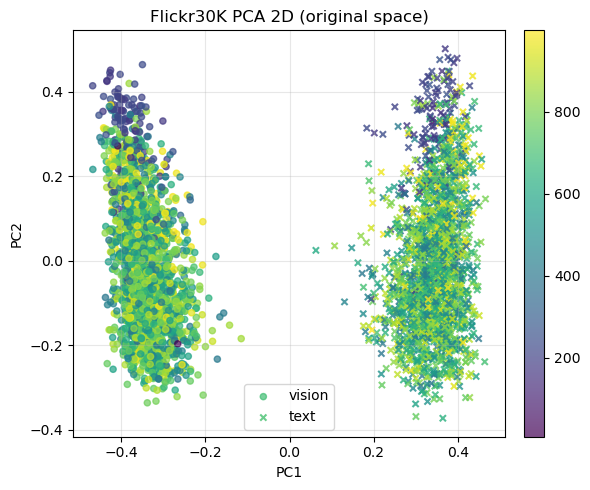

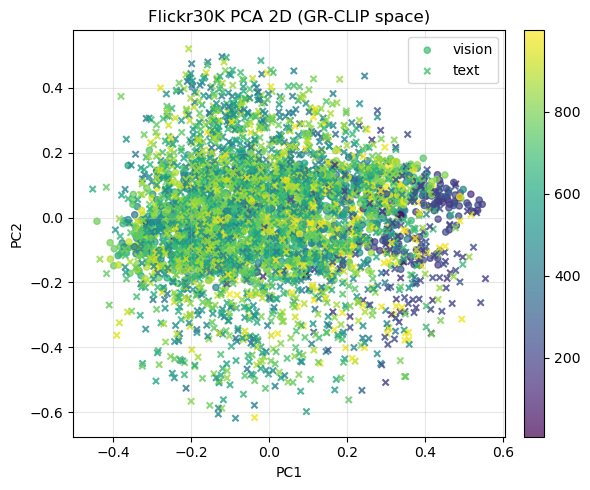

{'method': 'GR-CLIP',
 'dataset': 'flickr30k',
 'direction': 'text_to_vision',
 'grclip_stats': {'n_fit': 10000,
  'embedding_dim': 512,
  'query_text_mean_norm': 0.5413786768913269,
  'document_text_mean_norm': 0.5413786768913269,
  'document_image_mean_norm': 0.5756060481071472},
 'retrieval_orig': {1: 0.5694831609725952,
  5: 0.8008203506469727,
  10: 0.8656275868415833},
 'retrieval_aligned': {1: 0.5338802337646484,
  5: 0.764561116695404,
  10: 0.8400328159332275},
 'gaps_orig': {'L2M': 0.6853559613227844,
  'L2I': 1.1632107496261597,
  'cosineTP': 0.32275527715682983,
  'RMG': 0.7977277144749543},
 'gaps_aligned': {'L2M': 0.019340697675943375,
  'L2I': 1.1323096752166748,
  'cosineTP': 0.3559030294418335,
  'RMG': 0.7203946802075843},
 'mean_rmg_over_batches': {'orig': 0.7977277144749543,
  'aligned': 0.7203946802075843},
 'clustering_orig': {'ARI': 0.05909677586457568,
  'NMI': np.float64(0.5437534413578959),
  'Homogeneity': np.float64(0.5646756239089785),
  'V-measure': np.flo

In [3]:
def eval_grclip_flickr30k(test_loader, statistics, max_cluster_samples=5000, plot_pca=True):
    Xt_all, Xv_all, Xt_gr_all, Xv_gr_all, labels_all = collect_grclip_eval_embeddings(
        test_loader,
        statistics,
        device=device,
        max_eval_batches=None,
    )

    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval("flickr30k", (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("flickr30k", (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("flickr30k", (Xt_all, Xv_all), top_k=10))),
    }
    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval("flickr30k", (Xt_gr_all, Xv_gr_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("flickr30k", (Xt_gr_all, Xv_gr_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("flickr30k", (Xt_gr_all, Xv_gr_all), top_k=10))),
    }

    gaps_orig = _compute_gap_bundle(Xt_all, Xv_all)
    gaps_aligned = _compute_gap_bundle(Xt_gr_all, Xv_gr_all)
    mean_rmg = mean_rmg_over_batches(test_loader, statistics, device=device, text_role="query")
    gaps_orig["RMG"] = mean_rmg["orig"]
    gaps_aligned["RMG"] = mean_rmg["gr_clip"]

    cluster_limit = min(int(max_cluster_samples), Xt_all.shape[0])
    clustering_orig = _clustering_metrics_two_modalities_flickr30k(
        Xt_all[:cluster_limit],
        Xv_all[:cluster_limit],
        labels_all[:cluster_limit],
        n_clusters=len(train_class_dist),
    )
    clustering_aligned = _clustering_metrics_two_modalities_flickr30k(
        Xt_gr_all[:cluster_limit],
        Xv_gr_all[:cluster_limit],
        labels_all[:cluster_limit],
        n_clusters=len(train_class_dist),
    )

    out = {
        "method": "GR-CLIP",
        "dataset": "flickr30k",
        "direction": "text_to_vision",
        "grclip_stats": _summarize_grclip_statistics(statistics),
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": {
            "orig": mean_rmg["orig"],
            "aligned": mean_rmg["gr_clip"],
        },
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== GR-CLIP FLICKR30K RESULTS ===")
    print("Retrieval original  :", retrieval_orig)
    print("Retrieval aligned   :", retrieval_aligned)
    print("Mean RMG over batches:", out["mean_rmg_over_batches"])
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)

    if plot_pca:
        labels_np = labels_all[:cluster_limit].detach().cpu().numpy()
        emb_orig = torch.cat([Xt_all[:cluster_limit], Xv_all[:cluster_limit]], dim=0).numpy()
        emb_al = torch.cat([Xt_gr_all[:cluster_limit], Xv_gr_all[:cluster_limit]], dim=0).numpy()
        labels_2n = np.concatenate([labels_np, labels_np], axis=0)
        plot_pca_labeled(emb_orig, labels_2n, title="Flickr30K PCA 2D (original space)", max_points=min(4000, emb_orig.shape[0]))
        plot_pca_labeled(emb_al, labels_2n, title="Flickr30K PCA 2D (GR-CLIP space)", max_points=min(4000, emb_al.shape[0]))

    return out


grclip_stats_flickr30k = fit_grclip_statistics_from_loader(
    train_dataloader,
    n_fit=10_000,
    device=device,
    query_text_index=0,
    document_text_index=0,
    document_image_index=1,
)

results_grclip_flickr30k = eval_grclip_flickr30k(
    test_dataloader,
    grclip_stats_flickr30k,
    max_cluster_samples=5_000,
    plot_pca=True,
)

results_grclip_flickr30k


## MSCOCO


In [4]:
mscoco_train_dir = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip_imagenet"
mscoco_test_dir = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip_imagenet"

ds_train = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    mscoco_train_dir,
    split_name="train_shard",
    return_label_name=False,
)
ds_test = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    mscoco_test_dir,
    split_name="val_shard",
    return_label_name=False,
)


def _count_labels_dataset(dataset):
    counts = {}
    for i in range(len(dataset)):
        _, _, y = dataset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


train_counts = _count_labels_dataset(ds_train)
test_counts = _count_labels_dataset(ds_test)
keep_classes = {c for c in set(test_counts.keys()) if train_counts.get(c, 0) >= 10}

train_indices = [i for i in range(len(ds_train)) if int(ds_train[i][2].item()) in keep_classes]
test_indices = [i for i in range(len(ds_test)) if int(ds_test[i][2].item()) in keep_classes]

filtered_train = torch.utils.data.Subset(ds_train, train_indices)
filtered_test = torch.utils.data.Subset(ds_test, test_indices)

filtered_train_counts = _count_labels_dataset(filtered_train)
filtered_test_counts = _count_labels_dataset(filtered_test)
assert set(filtered_train_counts.keys()) == set(filtered_test_counts.keys())

N_CLUSTERS_MSCOCO_IMAGENET = len(filtered_train_counts)

train_loader_mscoco = DataLoader(
    filtered_train,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)
test_loader_mscoco = DataLoader(
    filtered_test,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)

print(f"Train classes after filter: {len(filtered_train_counts)}")
print(f"Test classes after filter: {len(filtered_test_counts)}")
print(f"Train samples after filter: {len(filtered_train)}")
print(f"Test samples after filter: {len(filtered_test)}")


[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 512)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 512)
Train classes after filter: 517
Test classes after filter: 517
Train samples after filter: 113777
Test samples after filter: 4963


RMG over batches: 100%|██████████| 20/20 [00:00<00:00, 233.83it/s]


=== GR-CLIP MSCOCO + IMAGENET LABELS RESULTS ===
Retrieval original  : {1: 0.36449727416038513, 5: 0.6296594738960266, 10: 0.7332258820533752}
Retrieval aligned   : {1: 0.3459601104259491, 5: 0.5877493619918823, 10: 0.7003828287124634}
Mean RMG over batches: {'orig': 0.80432542692993, 'aligned': 0.714288914038735}
Gaps original       : {'L2M': 0.7363729476928711, 'L2I': 1.178350806236267, 'cosineTP': 0.3050069510936737, 'RMG': 0.80432542692993}
Gaps aligned        : {'L2M': 0.026514483615756035, 'L2I': 1.1153106689453125, 'cosineTP': 0.3752892017364502, 'RMG': 0.714288914038735}


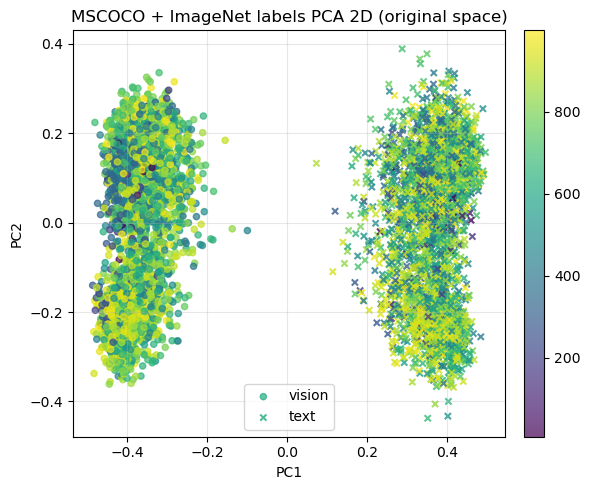

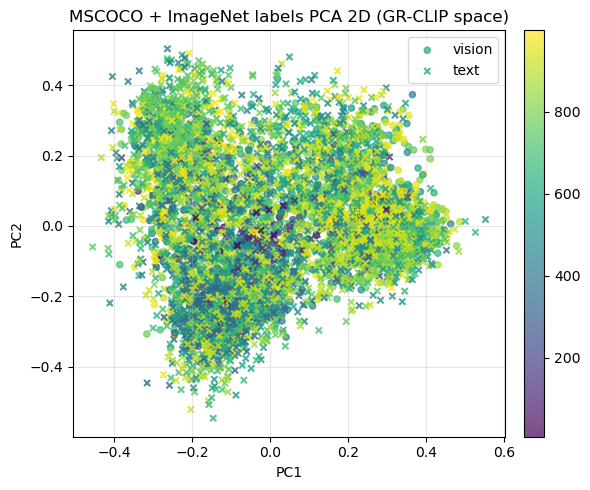

{'method': 'GR-CLIP',
 'dataset': 'mscoco_imagenet',
 'direction': 'text_to_vision',
 'grclip_stats': {'n_fit': 10000,
  'embedding_dim': 512,
  'query_text_mean_norm': 0.5748849511146545,
  'document_text_mean_norm': 0.5748849511146545,
  'document_image_mean_norm': 0.5603824853897095},
 'retrieval_orig': {1: 0.36449727416038513,
  5: 0.6296594738960266,
  10: 0.7332258820533752},
 'retrieval_aligned': {1: 0.3459601104259491,
  5: 0.5877493619918823,
  10: 0.7003828287124634},
 'gaps_orig': {'L2M': 0.7363729476928711,
  'L2I': 1.178350806236267,
  'cosineTP': 0.3050069510936737,
  'RMG': 0.80432542692993},
 'gaps_aligned': {'L2M': 0.026514483615756035,
  'L2I': 1.1153106689453125,
  'cosineTP': 0.3752892017364502,
  'RMG': 0.714288914038735},
 'mean_rmg_over_batches': {'orig': 0.80432542692993,
  'aligned': 0.714288914038735},
 'clustering_orig': {'ARI': 0.14013953924261072,
  'NMI': np.float64(0.6741491437501304),
  'Homogeneity': np.float64(0.7290975144288381),
  'V-measure': np.flo

In [5]:
def eval_grclip_mscoco_imagenet(test_loader, statistics, max_eval_batches=None, max_cluster_samples=3000, plot_pca=True):
    Xt_all, Xv_all, Xt_gr_all, Xv_gr_all, labels_all = collect_grclip_eval_embeddings(
        test_loader,
        statistics,
        device=device,
        max_eval_batches=max_eval_batches,
    )

    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_all, Xv_all), top_k=10))),
    }
    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_gr_all, Xv_gr_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_gr_all, Xv_gr_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("mscoco_imagenet_labels", (Xt_gr_all, Xv_gr_all), top_k=10))),
    }

    gaps_orig = _compute_gap_bundle(Xt_all, Xv_all)
    gaps_aligned = _compute_gap_bundle(Xt_gr_all, Xv_gr_all)
    mean_rmg = mean_rmg_over_batches(
        test_loader,
        statistics,
        device=device,
        max_eval_batches=max_eval_batches,
        text_role="query",
    )
    gaps_orig["RMG"] = mean_rmg["orig"]
    gaps_aligned["RMG"] = mean_rmg["gr_clip"]

    if max_cluster_samples is not None and Xt_all.shape[0] > max_cluster_samples:
        sel = torch.randperm(Xt_all.shape[0])[:max_cluster_samples]
        Xt_c = Xt_all[sel]
        Xv_c = Xv_all[sel]
        Xt_gr_c = Xt_gr_all[sel]
        Xv_gr_c = Xv_gr_all[sel]
        y_c = labels_all[sel]
    else:
        Xt_c = Xt_all
        Xv_c = Xv_all
        Xt_gr_c = Xt_gr_all
        Xv_gr_c = Xv_gr_all
        y_c = labels_all

    clustering_orig = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        Xt_c,
        Xv_c,
        y_c,
        n_clusters=N_CLUSTERS_MSCOCO_IMAGENET,
        random_state=0,
    )
    clustering_aligned = clustering_metrics_two_modalities_mscoco_imagenet_labels(
        Xt_gr_c,
        Xv_gr_c,
        y_c,
        n_clusters=N_CLUSTERS_MSCOCO_IMAGENET,
        random_state=0,
    )

    out = {
        "method": "GR-CLIP",
        "dataset": "mscoco_imagenet",
        "direction": "text_to_vision",
        "grclip_stats": _summarize_grclip_statistics(statistics),
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": {
            "orig": mean_rmg["orig"],
            "aligned": mean_rmg["gr_clip"],
        },
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== GR-CLIP MSCOCO + IMAGENET LABELS RESULTS ===")
    print("Retrieval original  :", retrieval_orig)
    print("Retrieval aligned   :", retrieval_aligned)
    print("Mean RMG over batches:", out["mean_rmg_over_batches"])
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)

    if plot_pca:
        labels_np = y_c.detach().cpu().numpy()
        emb_orig = torch.cat([Xt_c, Xv_c], dim=0).numpy()
        emb_al = torch.cat([Xt_gr_c, Xv_gr_c], dim=0).numpy()
        labels_2n = np.concatenate([labels_np, labels_np], axis=0)
        plot_pca_labeled(emb_orig, labels_2n, title="MSCOCO + ImageNet labels PCA 2D (original space)", max_points=min(6000, emb_orig.shape[0]))
        plot_pca_labeled(emb_al, labels_2n, title="MSCOCO + ImageNet labels PCA 2D (GR-CLIP space)", max_points=min(6000, emb_al.shape[0]))

    return out


grclip_stats_mscoco_imagenet = fit_grclip_statistics_from_loader(
    train_loader_mscoco,
    n_fit=10_000,
    device=device,
    query_text_index=0,
    document_text_index=0,
    document_image_index=1,
)

results_grclip_mscoco_imagenet = eval_grclip_mscoco_imagenet(
    test_loader_mscoco,
    grclip_stats_mscoco_imagenet,
    max_eval_batches=None,
    max_cluster_samples=3000,
    plot_pca=True,
)

results_grclip_mscoco_imagenet


## MSRVTT


In [6]:
msrvtt_train_dir = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train"
msrvtt_test_dir = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test"

msrvtt_train = MSRVTTEmbeddingsDatasetV2(
    msrvtt_train_dir,
    split_name="train_shard",
    return_metadata=False,
)
msrvtt_test = MSRVTTEmbeddingsDatasetV2(
    msrvtt_test_dir,
    split_name="test_shard",
    return_metadata=False,
)

train_loader_msrvtt = DataLoader(
    msrvtt_train,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    collate_fn=msrvtt_v2_collate_fn,
    generator=g,
)
test_loader_msrvtt = DataLoader(
    msrvtt_test,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    collate_fn=msrvtt_v2_collate_fn,
)

print(f"Train samples (v2): {len(msrvtt_train)}")
print(f"Test samples  (v2): {len(msrvtt_test)}")


[MSRVTTv2] 7010 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train | vision_emb=(7010, 512) | text_emb=(7010, 512) | num_classes=20
[MSRVTTv2] 1000 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test | vision_emb=(1000, 512) | text_emb=(1000, 512) | num_classes=20
Train samples (v2): 7010
Test samples  (v2): 1000


RMG over batches: 100%|██████████| 4/4 [00:00<00:00, 306.29it/s]


=== GR-CLIP MSRVTT v2 RESULTS ===
Retrieval original  : {1: 0.32600000500679016, 5: 0.5789999961853027, 10: 0.6859999895095825}
Retrieval aligned   : {1: 0.34599998593330383, 5: 0.5759999752044678, 10: 0.7009999752044678}
Mean RMG over batches: {'orig': 0.8380064872521648, 'aligned': 0.7497735126952625}
Gaps original       : {'L2M': 0.7806441187858582, 'L2I': 1.1991441249847412, 'cosineTP': 0.2800264060497284, 'RMG': 0.8380064872521648}
Gaps aligned        : {'L2M': 0.07942454516887665, 'L2I': 1.2191202640533447, 'cosineTP': 0.25315117835998535, 'RMG': 0.7497735126952625}


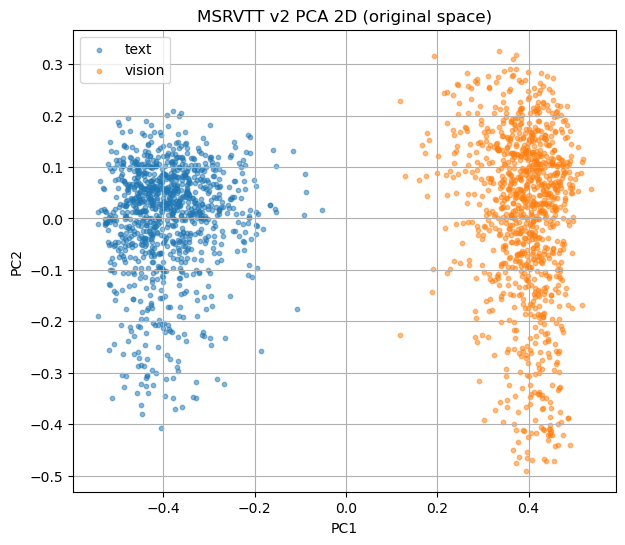

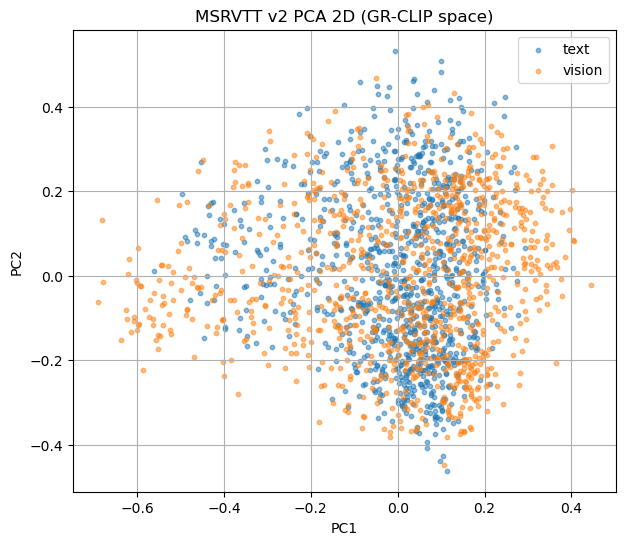

{'method': 'GR-CLIP',
 'dataset': 'msrvtt_v2',
 'direction': 'text_to_vision',
 'grclip_stats': {'n_fit': 7010,
  'embedding_dim': 512,
  'query_text_mean_norm': 0.6659067869186401,
  'document_text_mean_norm': 0.6659067869186401,
  'document_image_mean_norm': 0.655765950679779},
 'retrieval_orig': {1: 0.32600000500679016,
  5: 0.5789999961853027,
  10: 0.6859999895095825},
 'retrieval_aligned': {1: 0.34599998593330383,
  5: 0.5759999752044678,
  10: 0.7009999752044678},
 'gaps_orig': {'L2M': 0.7806441187858582,
  'L2I': 1.1991441249847412,
  'cosineTP': 0.2800264060497284,
  'RMG': 0.8380064872521648},
 'gaps_aligned': {'L2M': 0.07942454516887665,
  'L2I': 1.2191202640533447,
  'cosineTP': 0.25315117835998535,
  'RMG': 0.7497735126952625},
 'mean_rmg_over_batches': {'orig': 0.8380064872521648,
  'aligned': 0.7497735126952625},
 'clustering_orig': {'ARI': 0.11275031736661961,
  'NMI': np.float64(0.24479879838727361),
  'Homogeneity': np.float64(0.2474051032634846),
  'V-measure': np.fl

In [7]:
def eval_grclip_msrvtt(test_loader, statistics, max_eval_batches=None, max_cluster_samples=3000, n_clusters=20, plot_pca=True):
    Xt_all, Xv_all, Xt_gr_all, Xv_gr_all, labels_all = collect_grclip_eval_embeddings(
        test_loader,
        statistics,
        device=device,
        max_eval_batches=max_eval_batches,
    )

    retrieval_orig = {
        1: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("msrvtt", (Xt_all, Xv_all), top_k=10))),
    }
    retrieval_aligned = {
        1: float(_to_scalar(compute_retrieval("msrvtt", (Xt_gr_all, Xv_gr_all), top_k=1))),
        5: float(_to_scalar(compute_retrieval("msrvtt", (Xt_gr_all, Xv_gr_all), top_k=5))),
        10: float(_to_scalar(compute_retrieval("msrvtt", (Xt_gr_all, Xv_gr_all), top_k=10))),
    }

    gaps_orig = _compute_gap_bundle(Xt_all, Xv_all)
    gaps_aligned = _compute_gap_bundle(Xt_gr_all, Xv_gr_all)
    mean_rmg = mean_rmg_over_batches(
        test_loader,
        statistics,
        device=device,
        max_eval_batches=max_eval_batches,
        text_role="query",
    )
    gaps_orig["RMG"] = mean_rmg["orig"]
    gaps_aligned["RMG"] = mean_rmg["gr_clip"]

    clustering_orig = None
    clustering_aligned = None
    if labels_all is not None and Xt_all.shape[0] > 0:
        n_use = min(Xt_all.shape[0], max_cluster_samples)
        if n_use < Xt_all.shape[0]:
            sel = torch.randperm(Xt_all.shape[0])[:n_use]
            Xt_cl = Xt_all[sel]
            Xv_cl = Xv_all[sel]
            Xt_gr_cl = Xt_gr_all[sel]
            Xv_gr_cl = Xv_gr_all[sel]
            labels_cl = labels_all[sel]
        else:
            Xt_cl = Xt_all
            Xv_cl = Xv_all
            Xt_gr_cl = Xt_gr_all
            Xv_gr_cl = Xv_gr_all
            labels_cl = labels_all

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_cl,
            Xv_cl,
            labels_cl,
            n_clusters=n_clusters,
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_gr_cl,
            Xv_gr_cl,
            labels_cl,
            n_clusters=n_clusters,
        )

    out = {
        "method": "GR-CLIP",
        "dataset": "msrvtt_v2",
        "direction": "text_to_vision",
        "grclip_stats": _summarize_grclip_statistics(statistics),
        "retrieval_orig": retrieval_orig,
        "retrieval_aligned": retrieval_aligned,
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_aligned,
        "mean_rmg_over_batches": {
            "orig": mean_rmg["orig"],
            "aligned": mean_rmg["gr_clip"],
        },
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

    print("=== GR-CLIP MSRVTT v2 RESULTS ===")
    print("Retrieval original  :", retrieval_orig)
    print("Retrieval aligned   :", retrieval_aligned)
    print("Mean RMG over batches:", out["mean_rmg_over_batches"])
    print("Gaps original       :", gaps_orig)
    print("Gaps aligned        :", gaps_aligned)

    if plot_pca:
        emb_orig = torch.cat([Xt_all, Xv_all], dim=0).numpy()
        emb_al = torch.cat([Xt_gr_all, Xv_gr_all], dim=0).numpy()
        modality_labels = np.array(["text"] * Xt_all.shape[0] + ["vision"] * Xv_all.shape[0], dtype=object)
        plot_pca_modalities(emb_orig, modality_labels, title="MSRVTT v2 PCA 2D (original space)", max_points=4000)
        plot_pca_modalities(emb_al, modality_labels, title="MSRVTT v2 PCA 2D (GR-CLIP space)", max_points=4000)

    return out


grclip_stats_msrvtt = fit_grclip_statistics_from_loader(
    train_loader_msrvtt,
    n_fit=10_000,
    device=device,
    query_text_index=0,
    document_text_index=0,
    document_image_index=1,
)

results_grclip_msrvtt = eval_grclip_msrvtt(
    test_loader_msrvtt,
    grclip_stats_msrvtt,
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    plot_pca=True,
)

results_grclip_msrvtt


## Export the results


In [8]:
# Export only compact metric summaries, not statistics tensors or large arrays.
import json


def _to_float_dict(d):
    if d is None:
        return None
    return {str(k): float(v) for k, v in d.items()}


def _summarize_result(result):
    summary = {
        "method": result.get("method"),
        "dataset": result.get("dataset"),
        "direction": result.get("direction"),
        "grclip_stats": result.get("grclip_stats"),
        "retrieval_orig": _to_float_dict(result.get("retrieval_orig")),
        "retrieval_aligned": _to_float_dict(result.get("retrieval_aligned")),
        "gaps_orig": _to_float_dict(result.get("gaps_orig")),
        "gaps_aligned": _to_float_dict(result.get("gaps_aligned")),
        "mean_rmg_over_batches": _to_float_dict(result.get("mean_rmg_over_batches")),
    }

    clustering_orig = result.get("clustering_orig")
    clustering_aligned = result.get("clustering_aligned")
    if clustering_orig is not None:
        summary["clustering_orig"] = {
            "ARI": float(clustering_orig["ARI"]),
            "NMI": float(clustering_orig["NMI"]),
            "Homogeneity": float(clustering_orig["Homogeneity"]),
            "V-measure": float(clustering_orig["V-measure"]),
        }
    if clustering_aligned is not None:
        summary["clustering_aligned"] = {
            "ARI": float(clustering_aligned["ARI"]),
            "NMI": float(clustering_aligned["NMI"]),
            "Homogeneity": float(clustering_aligned["Homogeneity"]),
            "V-measure": float(clustering_aligned["V-measure"]),
        }

    return summary


results_to_save = {
    "flickr30k": _summarize_result(results_grclip_flickr30k),
    "mscoco_imagenet": _summarize_result(results_grclip_mscoco_imagenet),
    "msrvtt_v2": _summarize_result(results_grclip_msrvtt),
}

export_path = "grclip_evaluation_results.json"
with open(export_path, "w") as f:
    json.dump(results_to_save, f, indent=2)

print(f"Saved compact GR-CLIP metrics to {export_path}")


Saved compact GR-CLIP metrics to grclip_evaluation_results.json
